In [1]:
using LinearAlgebra
using Distributions
using LaTeXStrings
using Printf
using FileIO
import JLD2

In [2]:
using DataFrames

In [3]:
using Revise
using Newtrinos
using Newtrinos.osc

[ Info: Precompiling Newtrinos [5b289081-bab5-45e8-97fc-86872f1653a0] (cache misses: include_dependency fsize change (2), wrong dep version loaded (2))
[ Info: Setting new default BAT context BATContext{Float64}(Random123.Philox4x{UInt64, 10}(0xf14b8f47f470de25, 0x3542268199911d6d, 0x27189f24cac444ff, 0x5e619000d87e51b0, 0x8826da8e5acdc484, 0x23c26917f93a9481, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0), HeterogeneousComputing.CPUnit(), BAT._NoADSelected())


In [4]:
osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.NND(),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

Newtrinos.osc.Osc(OscillationConfig{NND, SI, Basic, Newtrinos.osc.All}(NND(ThreeFlavour(:NO)), SI(), Basic(), Newtrinos.osc.All()), (m₀ = 0.01, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761, δCP = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, N = 100.0, r = 1.0), (m₀ = Uniform{Float64}(a=0.001, b=2.0), θ₁₂ = Uniform{Float64}(a=0.4205343352839651, b=0.7853981633974483), θ₁₃ = Uniform{Float64}(a=0.1, b=0.2), θ₂₃ = Uniform{Float64}(a=0.5235987755982988, b=1.0471975511965976), δCP = Uniform{Float64}(a=0.0, b=6.283185307179586), Δm²₂₁ = Uniform{Float64}(a=6.5e-5, b=9.0e-5), Δm²₃₁ = Uniform{Float64}(a=0.002, b=0.003), N = Uniform{Float64}(a=40.0, b=80.0), r = Uniform{Float64}(a=1.0e-8, b=1.0)), Newtrinos.osc.var"#get_Nnaturalness#52"(), Newtrinos.osc.var"#osc_prob#43"{Newtrinos.osc.var"#osc_prob#41#44"{OscillationConfig{NND, SI, Basic, Newtrinos.osc.All}}}(Newtrinos.osc.var"#osc_prob#41#44"{OscillationConfig{NND, SI, Basic, Newtrinos.osc.All}}(Oscillatio

In [5]:

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics = (; osc, atm_flux, earth_layers);

In [6]:
experiments = (
 
    dayabay = Newtrinos.dayabay.configure(physics),
);

[ Info: Loading dayabay data


In [7]:
p = Newtrinos.get_params(experiments)

(N = 100.0, m₀ = 0.01, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

Doesnt return same  m01
9.899015925667326e-5
Doesnt return same  m02
0.00024983958993307084
Doesnt return same  m03
0.005048581368887033


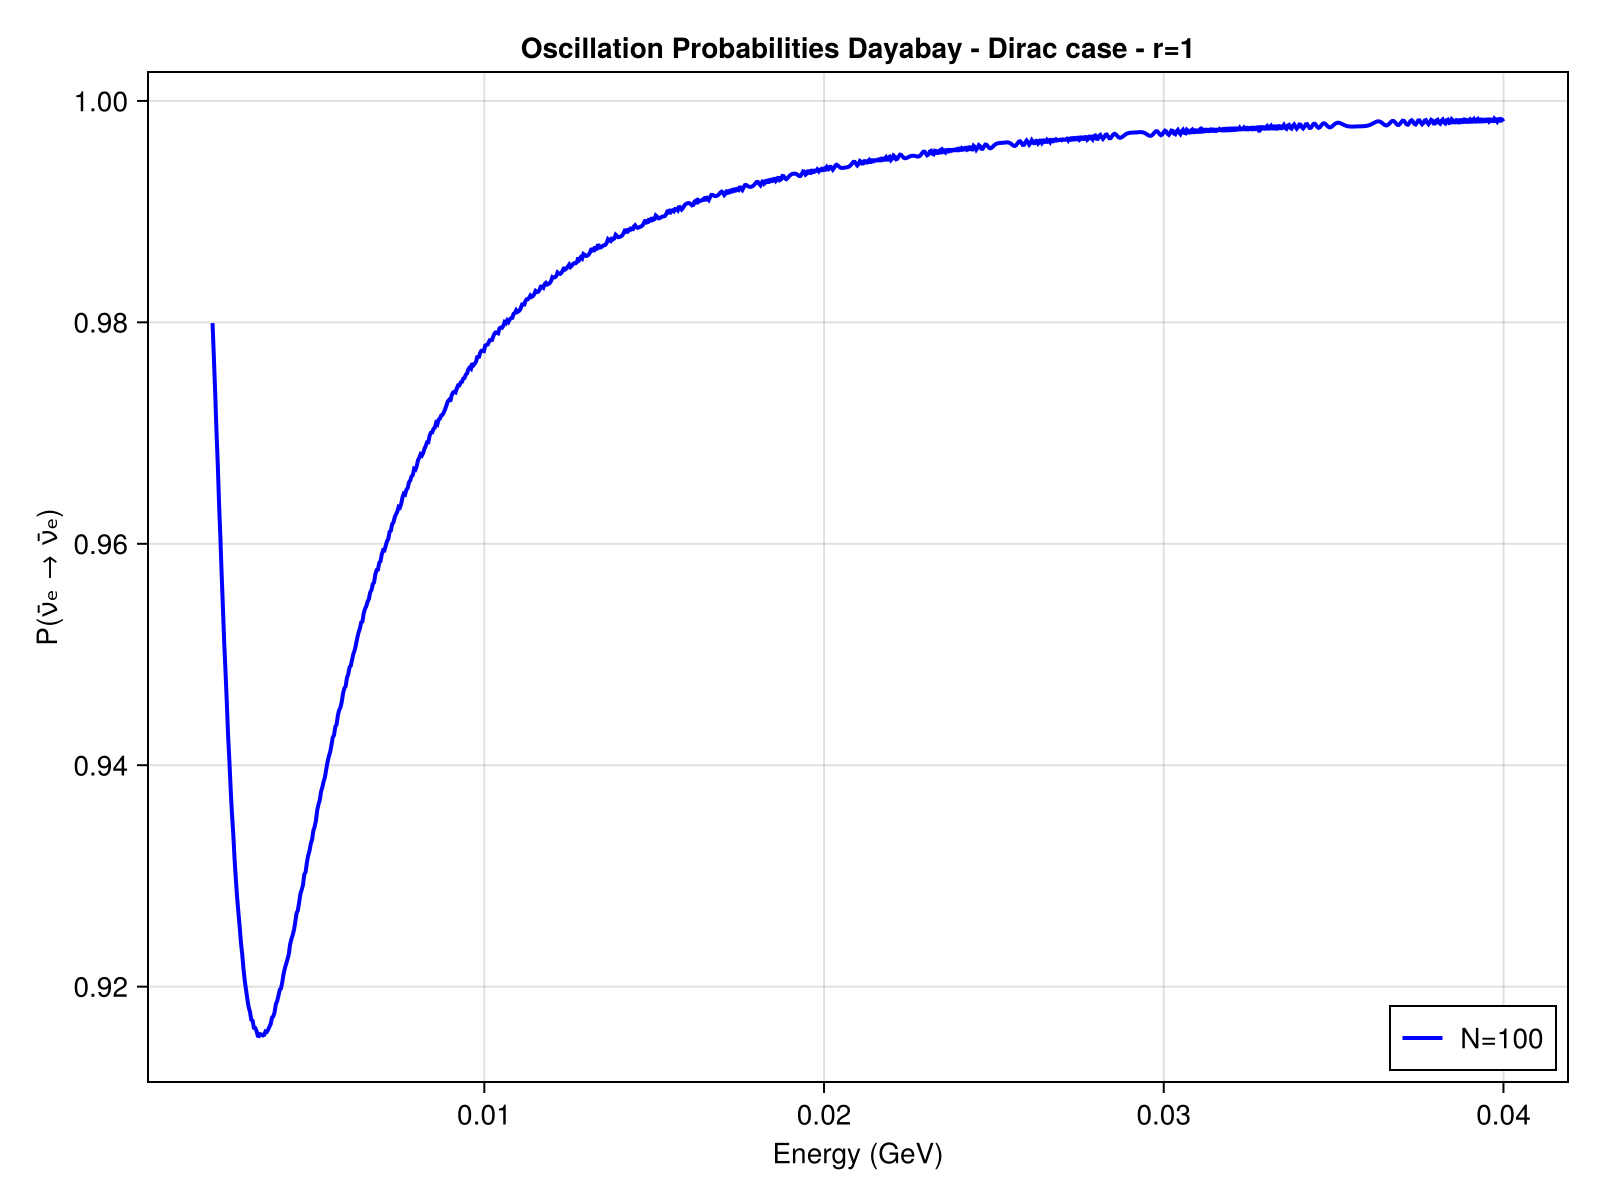

CairoMakie.Screen{IMAGE}


In [8]:
using CairoMakie
E_range = range(0.002, 0.04, length=1000) 
L=1.663
L_vec = [L]


osc_prob = Newtrinos.osc.get_osc_prob(osc_cfg)

p= Newtrinos.get_params(experiments)
p_5 = merge(p, (N = ftype(100),))


probab_5 = osc_prob(collect(E_range), L_vec, p_5; anti=true)

fig = Figure(size=(800, 600))
ax = Axis(fig[1,1], 
    xlabel = "Energy (GeV)",
    ylabel = "P(ν̄ₑ → ν̄ₑ)", 
    title = "Oscillation Probabilities Dayabay - Dirac case - r=1"
)

# Plot the lines
#lines!(ax, E_range, probab_SM[:, 1, 1,1], label="SM", linewidth=2, color=:green)
lines!(ax, E_range, probab_5[:, 1, 1,1], label=" N=100", linewidth=2, color=:blue)


# Add legend and set limits
axislegend(ax, position=:rb)

display(fig)


Doesnt return same  m01
7.626960959846319e-5
Doesnt return same  m02
0.0002327656310757036
Doesnt return same  m03
0.005005084510044033
Doesnt return same  m01
7.626960959846319e-5
Doesnt return same  m02
0.0002327656310757036
Doesnt return same  m03
0.005005084510044033
Doesnt return same  m01
7.626960959846319e-5
Doesnt return same  m02
0.0002327656310757036
Doesnt return same  m03
0.005005084510044033
Doesnt return same  m01
7.626960959846319e-5
Doesnt return same  m02
0.0002327656310757036
Doesnt return same  m03
0.005005084510044033
Doesnt return same  m01
7.626960959846319e-5
Doesnt return same  m02
0.0002327656310757036
Doesnt return same  m03
0.005005084510044033
Doesnt return same  m01
7.626960959846319e-5
Doesnt return same  m02
0.0002327656310757036
Doesnt return same  m03
0.005005084510044033
Doesnt return same  m01
8.905653279951868e-5
Doesnt return same  m02
0.00024236072377894493
Doesnt return same  m03
0.005029105773228788
Doesnt return same  m01
8.905653279951868e-5
Do

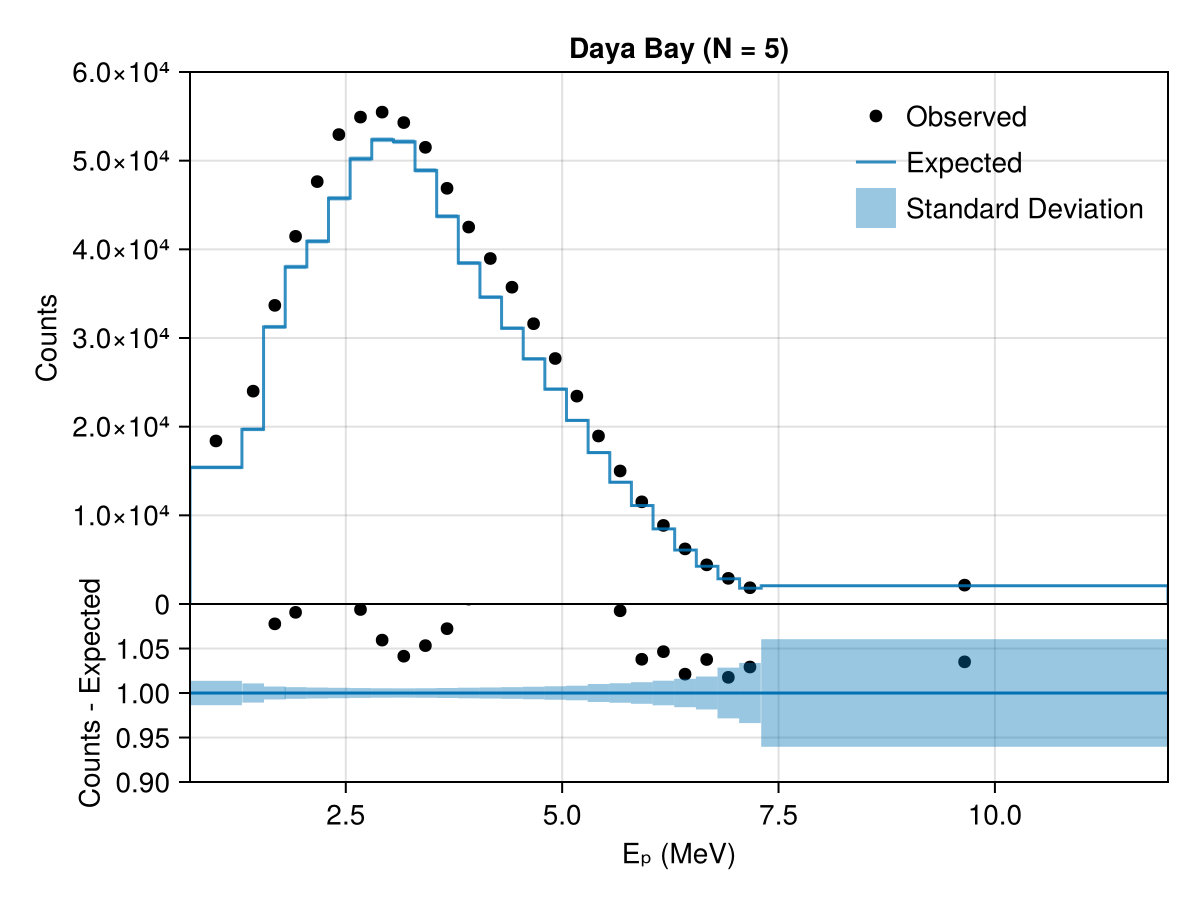

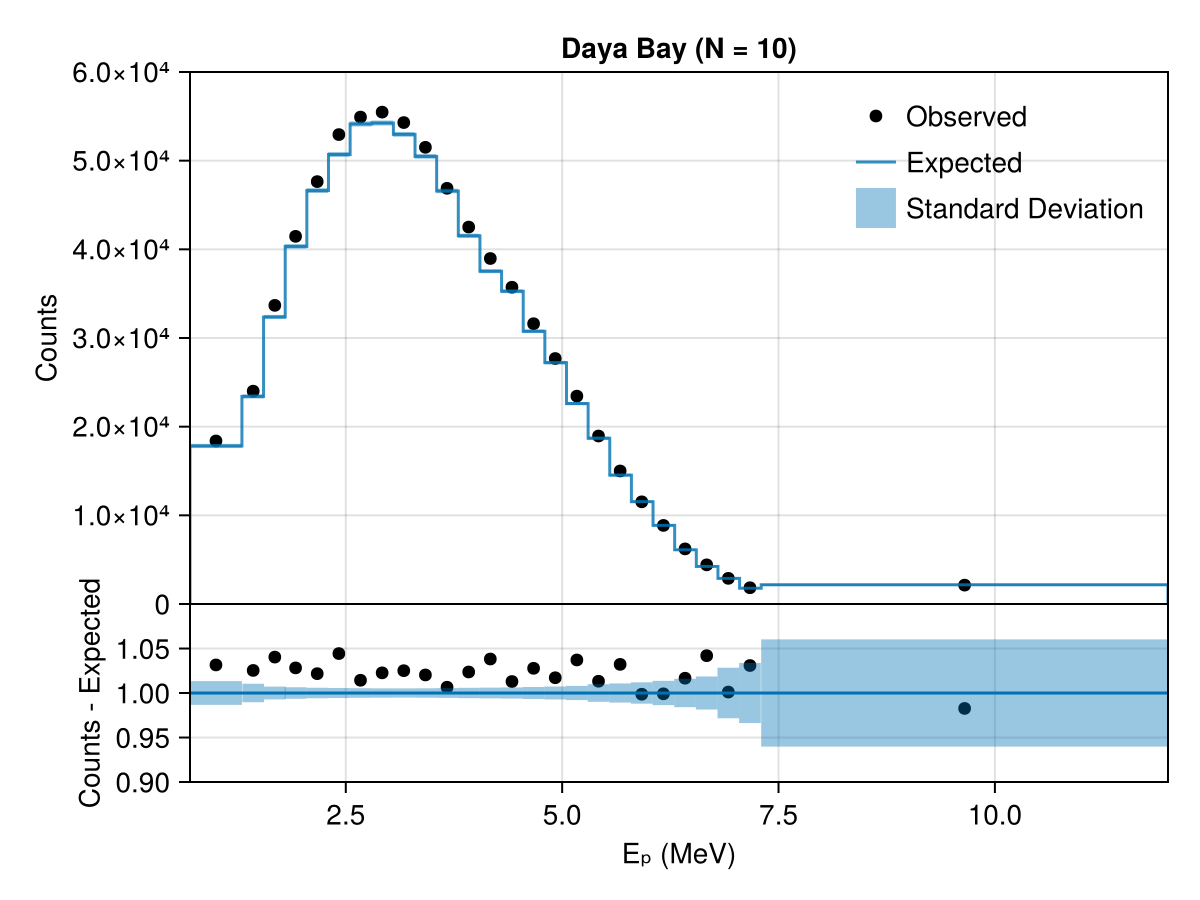

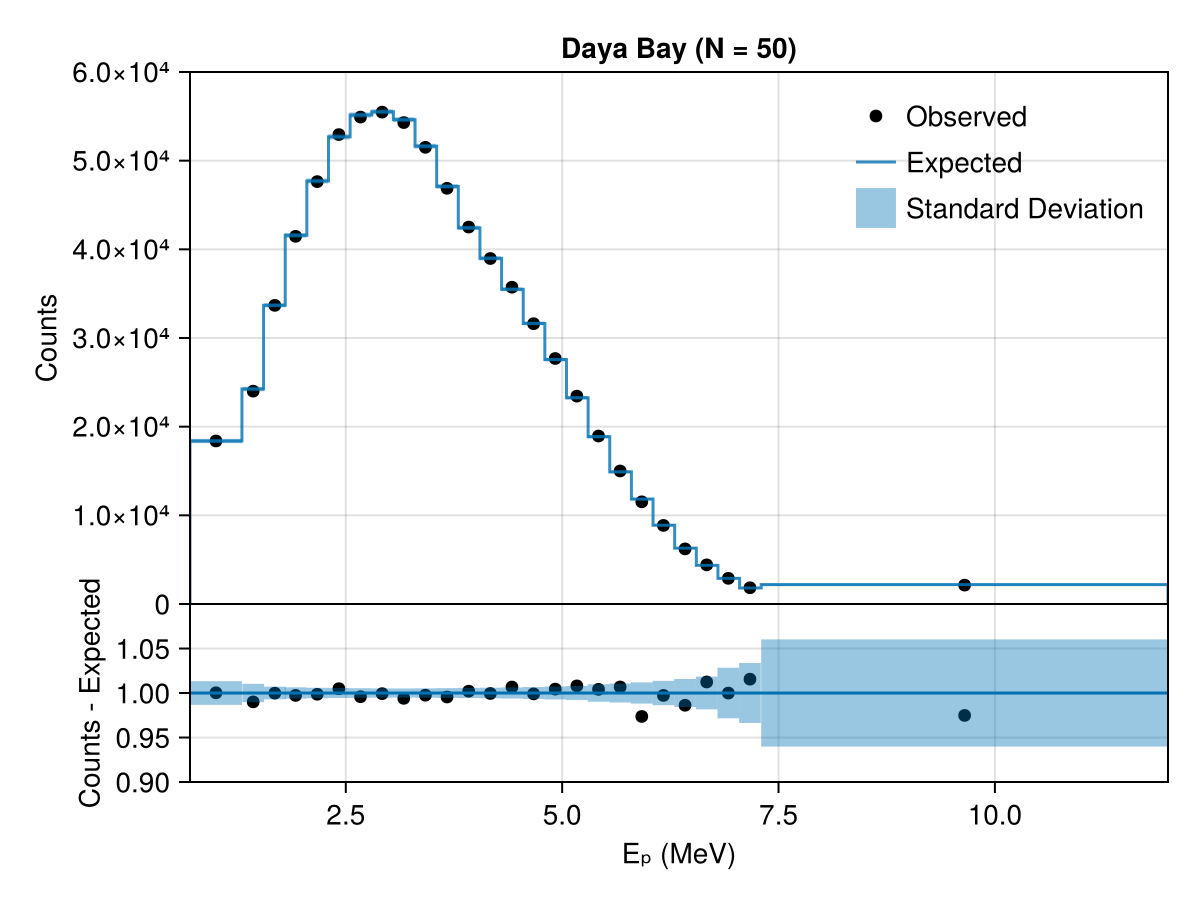

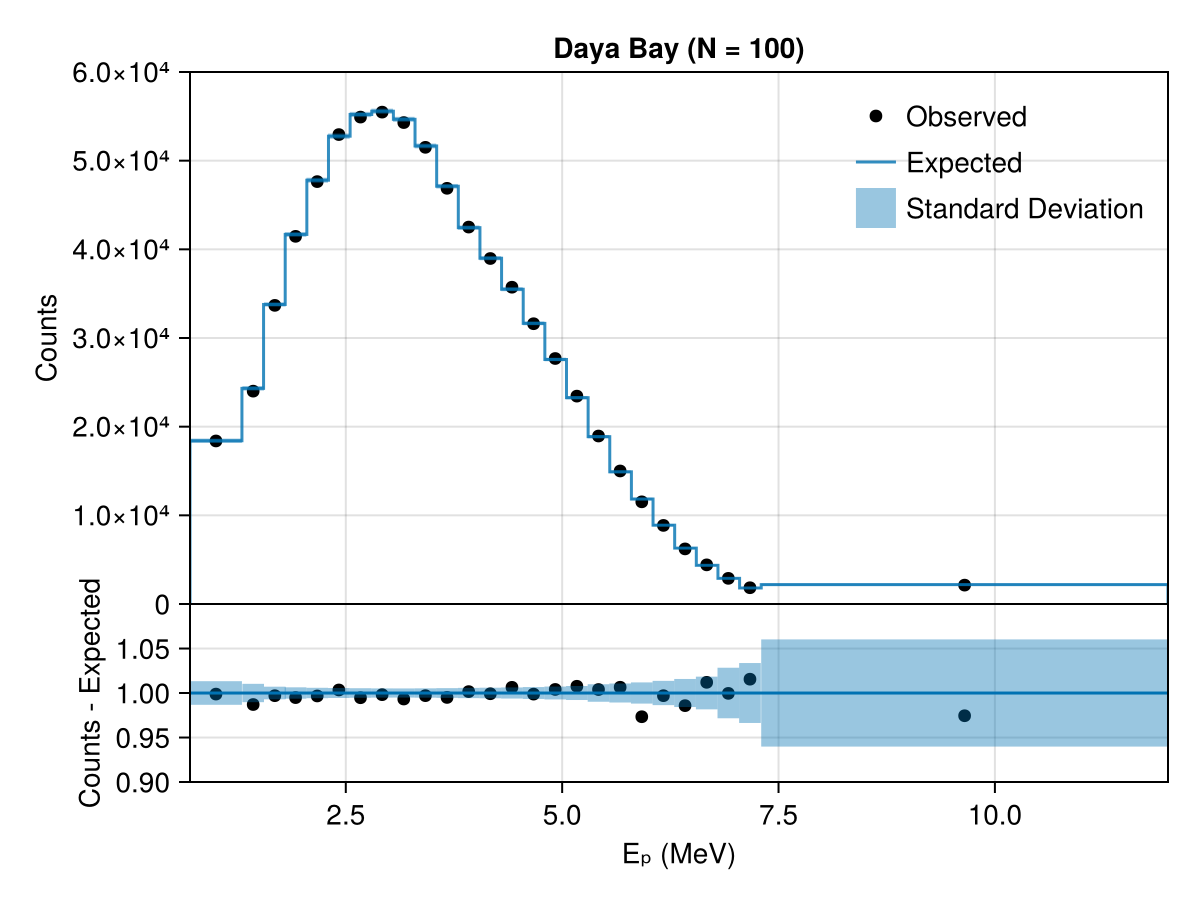

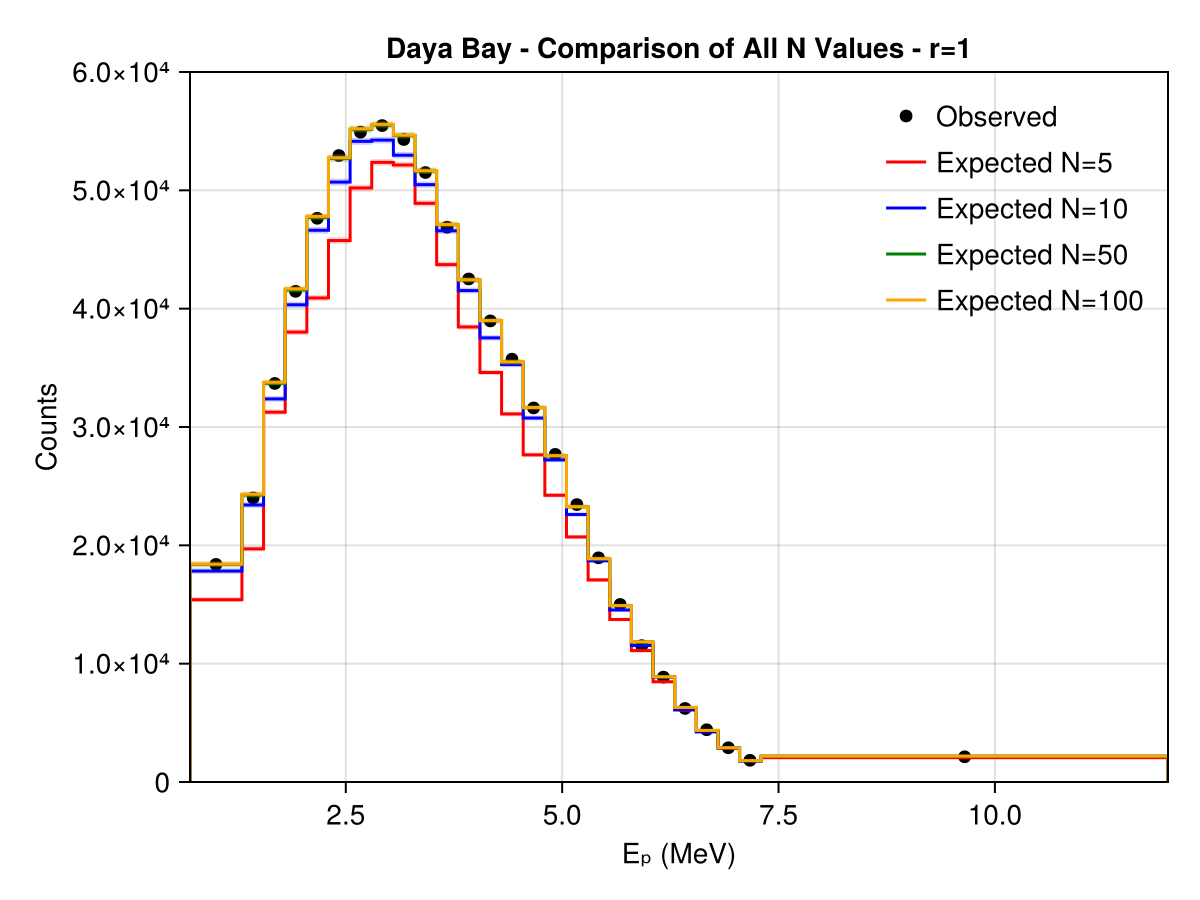

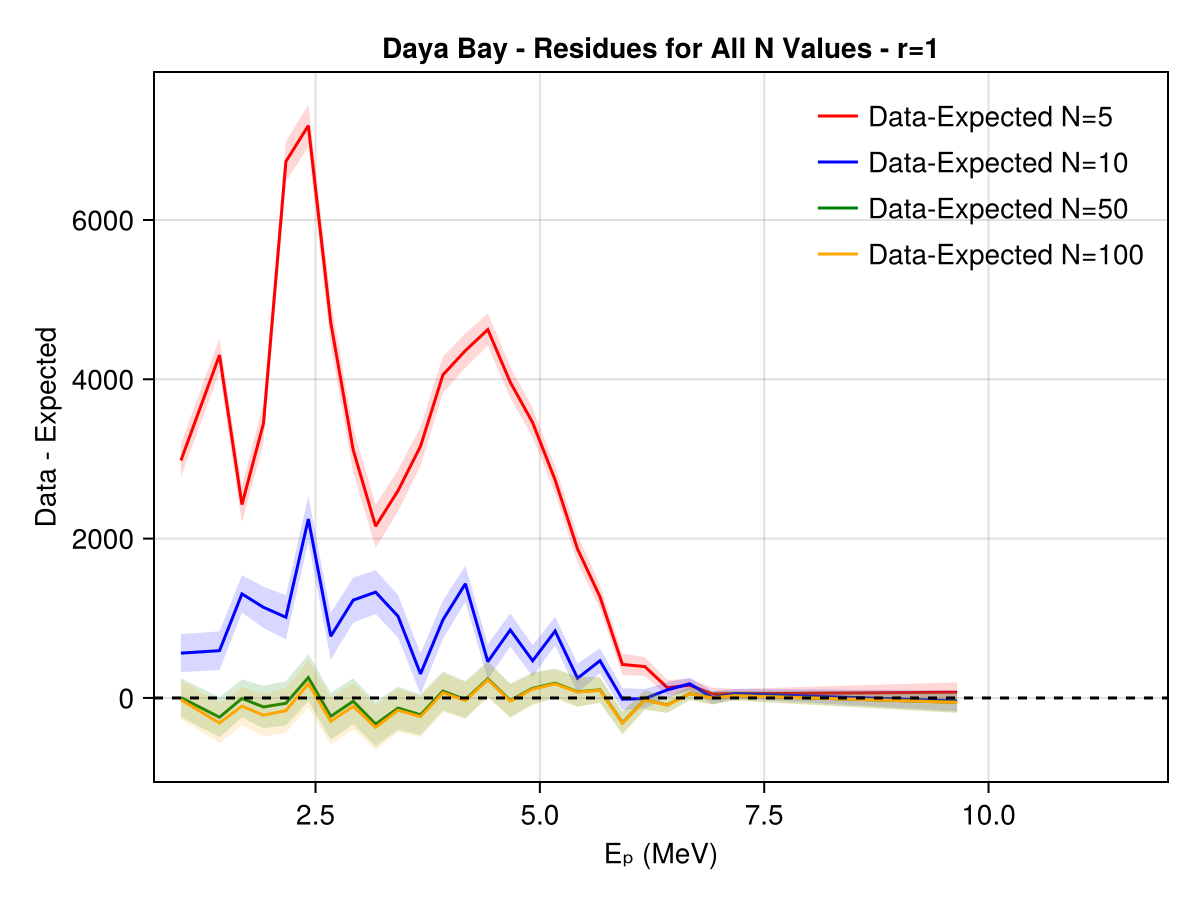

LoadError: SYSTEM: show(lasterr) caused an error

In [9]:
img = experiments.dayabay.plot(p)
display("image/png", img)
#save("/home/sofialon/Newtrinos.jl/profiled plot/dayabay/dayabay_data_NND_100_0.png", img)

In [ ]:

all_priors = Newtrinos.get_priors(experiments)


vars_to_scan = (r=31, N=31)  

modified_priors = (
    N = all_priors.N,
    m₀ =p.m₀,
    r = all_priors.r,
    
   
  

    Δm²₂₁ = p.Δm²₂₁,  
    Δm²₃₁ =all_priors.Δm²₃₁ , 
    δCP = p.δCP,    
    θ₁₂ = p.θ₁₂,    
    θ₁₃= all_priors.θ₁₃,       
    θ₂₃ = p.θ₂₃   
    

)


(N = Uniform{Float64}(a=40.0, b=80.0), m₀ = 0.01, r = Uniform{Float64}(a=0.0, b=1.0), Δm²₂₁ = 7.53e-5, Δm²₃₁ = Uniform{Float64}(a=0.002, b=0.003), δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = Uniform{Float64}(a=0.1, b=0.2), θ₂₃ = 0.8556288707523761)

In [ ]:

likelihood = Newtrinos.generate_likelihood(experiments);


In [ ]:

result = Newtrinos.scan(likelihood, modified_priors, vars_to_scan, p)

Progress:  10%|████                                     |  ETA: 0:59:51

In [ ]:
JLD2.@save "scan_dayabay_Nr_80_NND_m0=0.01_new.jld2" result

In [ ]:
using CairoMakie

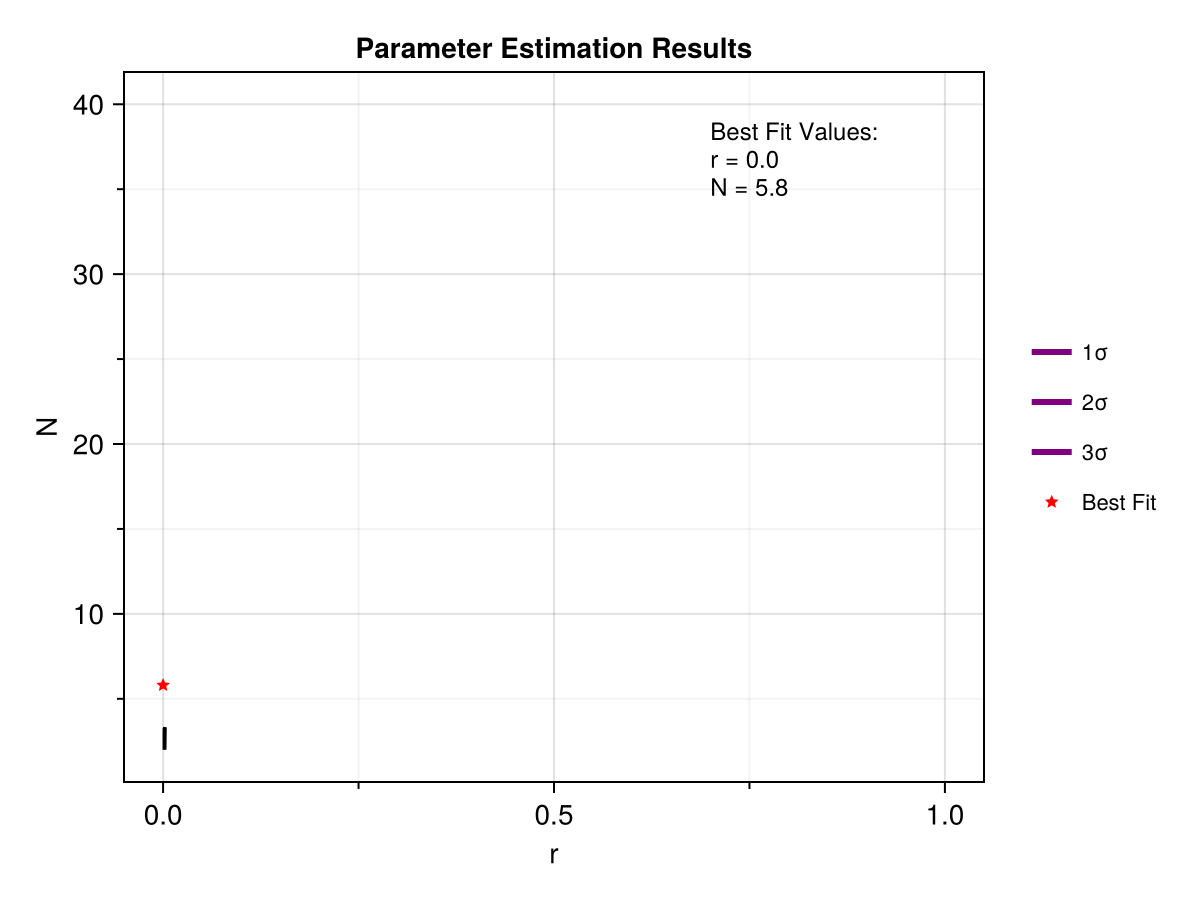

In [ ]:
img = CairoMakie.plot(result)
display("image/png", img)
save("/home/sofialon/Newtrinos.jl/aug_plots/dayabay/scan_dayabay_Nr_80_NND_m0=0.01_new.png", img)


┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


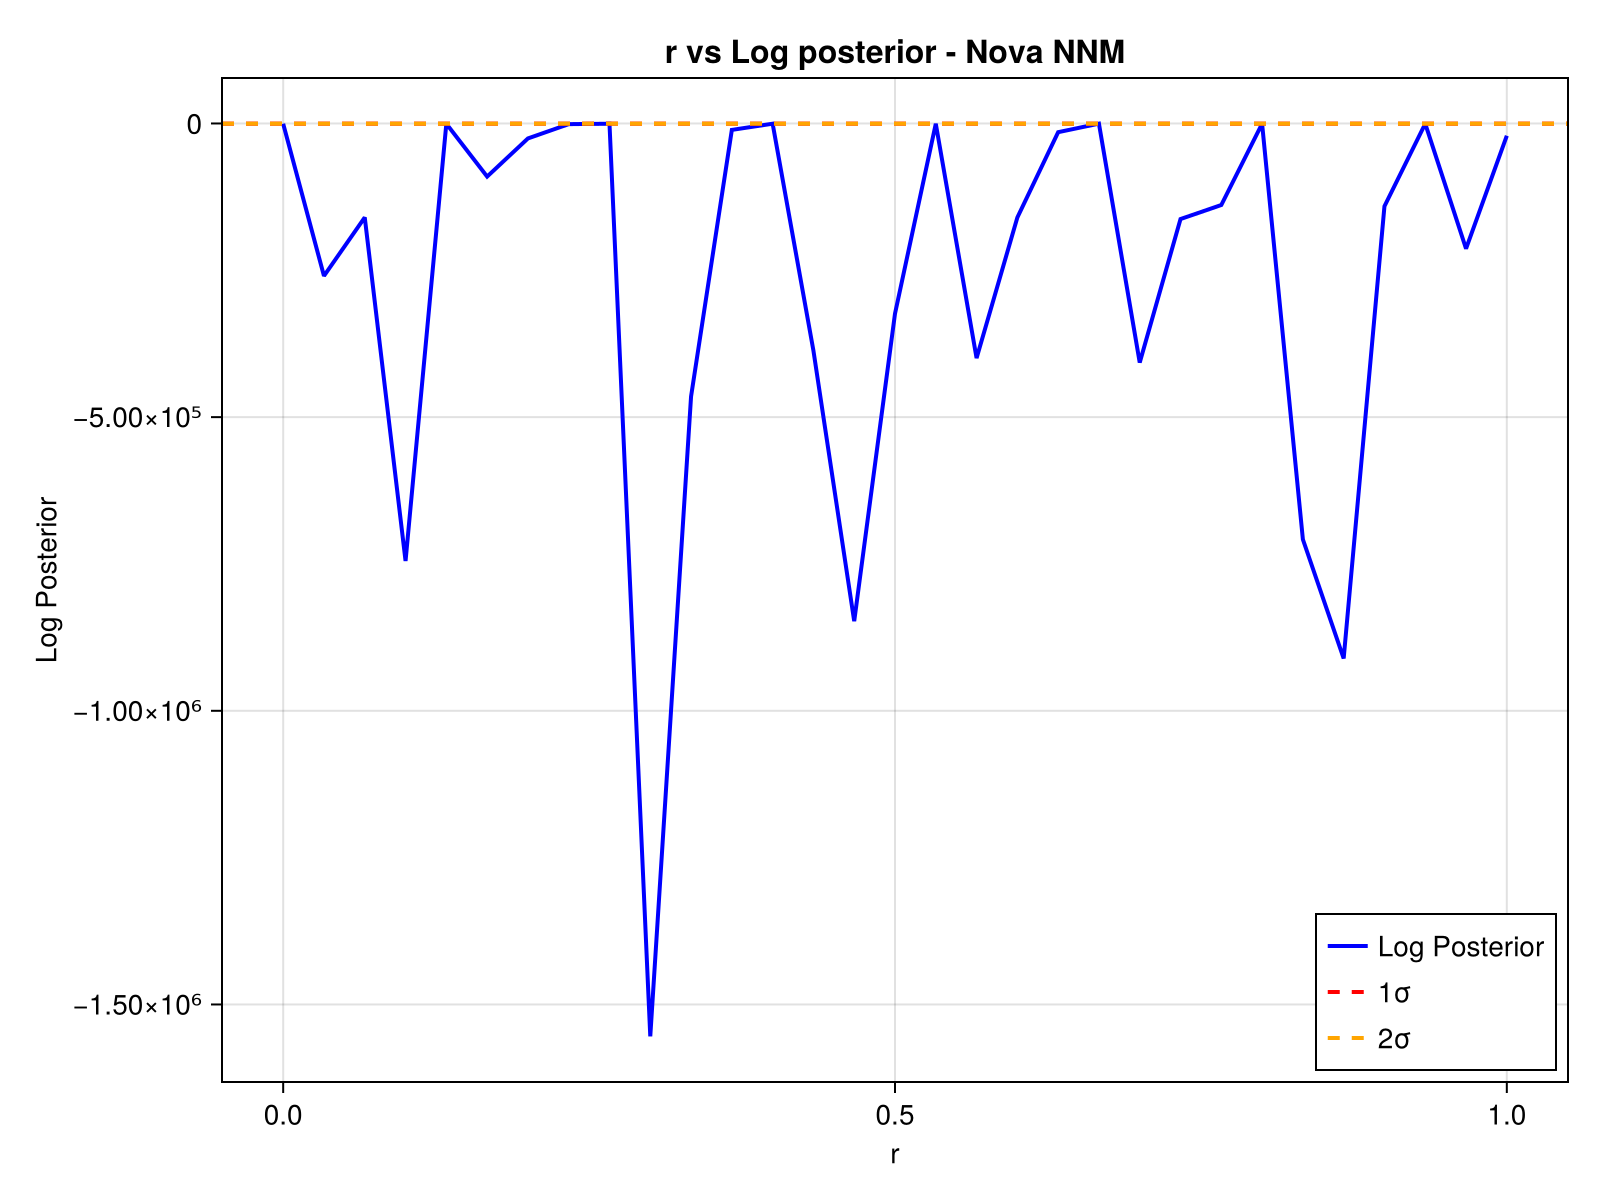

In [ ]:
bf = Newtrinos.bestfit(result)

# Calculate confidence intervals
sigma_1_threshold = maximum(result.values.log_posterior[:, 15]) - 0.5
sigma_2_threshold = maximum(result.values.log_posterior[:, 15]) - 2.0

# Create the plot
fig = Figure(resolution = (800, 600))
ax = Axis(fig[1, 1],
    xlabel = "r",
    ylabel = "Log Posterior",
    title = "r vs Log posterior - Nova NNM",
    titlesize = 16,
    xlabelsize = 14,
    ylabelsize = 14
)

# Plot the main curve
lines!(ax, result.axes.r, result.values.log_posterior[:, 25],
    color = :blue,
    linewidth = 2,
    label = "Log Posterior"
)

# Add confidence level lines
hlines!(ax, [sigma_1_threshold], 
    color = :red, 
    linestyle = :dash, 
    linewidth = 2,
    label = "1σ"
)

hlines!(ax, [sigma_2_threshold], 
    color = :orange, 
    linestyle = :dash, 
    linewidth = 2,
    label = "2σ"
)

# Add legend
axislegend(ax, position = :rb)  # right bottom

display("image/png", fig)
#save("/home/sofialon/Newtrinos.jl/profiled plot/dayabay/dayabay_rLogpost_N=50_m0=0.1_NND.png", fig)


Oscillations


In [9]:

# STANDARD MODEL
E_range = range(0.002, 0.04, length=1000) 
L=1.663
L_vec = [L]

osc_cfg_SM = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.ThreeFlavour(),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc_SM = Newtrinos.osc.configure(osc_cfg_SM)
 

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics_SM = (; osc=osc_SM, atm_flux, earth_layers);


experiments_SM = (
 
    dayabay = Newtrinos.dayabay.configure(physics_SM),
);

p_SM = Newtrinos.get_params(experiments_SM)

osc_prob_SM = Newtrinos.osc.get_osc_prob(osc_cfg_SM)


probab_SM = osc_prob_SM(collect(E_range), L_vec, p; anti=true)

[ Info: Loading dayabay data


1000×1×3×3 Array{Float64, 4}:
[:, :, 1, 1] =
 0.9717520812960653
 0.9683109007040173
 0.9648651711561107
 0.9614516539986672
 0.9581006425040238
 0.954836715800887
 0.9516794498955481
 0.948644075884838
 0.9457420805008407
 0.9429817476633987
 0.94036864212353
 0.9379060378509995
 0.9355952947774657
 ⋮
 0.9985934515549718
 0.9985961358673033
 0.9985988125173264
 0.9986014815341185
 0.9986041429466216
 0.9986067967836391
 0.9986094430738394
 0.9986120818457556
 0.9986147131277864
 0.998617336948196
 0.9986199533351169
 0.9986225623165482

[:, :, 2, 1] =
 0.005418083717743282
 0.006640561788994135
 0.007947011695303933
 0.009315085502218932
 0.01072495802678424
 0.012159222438124659
 0.013602747738296124
 0.015042513386734001
 0.016467432457965777
 0.017868171654777297
 0.019236974100273762
 0.02056748897953614
 0.02185461068877964
 ⋮
 0.000857674820230858
 0.0008560528141375867
 0.0008544353946927165
 0.0008528225446588595
 0.0008512142468793375
 0.000849610484277723
 0.0008480112398574

In [18]:
# NNATURALNESS WITH DIFFERENT N 


osc_prob = Newtrinos.osc.get_osc_prob(osc_cfg)

p= Newtrinos.get_params(experiments)
p_5 = merge(p, (N = ftype(5),))
p_10 = merge(p, (N = ftype(10),))
p_20 = merge(p, (N = ftype(20),))
p_50 = merge(p, (N = ftype(50),))

probab_5 = osc_prob(collect(E_range), L_vec, p_5; anti=true)
probab_10 = osc_prob(collect(E_range), L_vec, p_10; anti=true)
probab_20 = osc_prob(collect(E_range), L_vec, p_20; anti=true)
probab_50 = osc_prob(collect(E_range), L_vec, p_50; anti=true)

p_0 = merge(p, (r = ftype(1e-28),))
p_025 = merge(p,  (r = ftype(0.25),))
p_05 = merge(p,  (r = ftype(0.5),))
p_1 = merge(p,  (r = ftype(1),))


probab_0 = osc_prob(collect(E_range), L_vec, p_0; anti=true)
probab_025 = osc_prob(collect(E_range), L_vec, p_025; anti=true)
probab_05 = osc_prob(collect(E_range), L_vec, p_05; anti=true)
probab_1 = osc_prob(collect(E_range), L_vec, p_1; anti=true)


Doesnt return same  m01
7.626960959846319e-5
Doesnt return same  m02
0.0002327656310757036
Doesnt return same  m03
0.005005084510044033
Doesnt return same  m01
8.905653279951868e-5
Doesnt return same  m02
0.00024236072377894493
Doesnt return same  m03
0.005029105773228788
Doesnt return same  m01
9.476055566977746e-5
Doesnt return same  m02
0.00024665473606418596
Doesnt return same  m03
0.005040192092558987
Doesnt return same  m01
9.796100741158195e-5
Doesnt return same  m02
0.00024906463898191676
Doesnt return same  m03
0.005046528687979262
Doesnt return same  m01
0.0001
Doesnt return same  m02
0.0002506
Doesnt return same  m03
0.005050599999999999
Doesnt return same  m01
9.974749132060548e-5
Doesnt return same  m02
0.00025040986096774186
Doesnt return same  m03
0.005048580825264272
Doesnt return same  m01
9.949501537153226e-5
Doesnt return same  m02
0.0002502197465813236
Doesnt return same  m03
0.005048581015086446
Doesnt return same  m01
9.899015925667326e-5
Doesnt return same  m02
0

1000×1×300×300 Array{Float64, 4}:
[:, :, 1, 1] =
 0.9799323638005868
 0.9769105075961461
 0.9737803681699908
 0.9703168963632534
 0.9672911338429909
 0.963758184205305
 0.9607819448123227
 0.9573967255668464
 0.9543213061041624
 0.9511298307918207
 0.9485527291174346
 0.945777336588149
 0.9427624244499878
 ⋮
 0.9981314672444781
 0.9982187411689922
 0.9984167246873165
 0.998059748451035
 0.9983900437319072
 0.9982666670927219
 0.9981358939618563
 0.9984662077723051
 0.9980954129191101
 0.9983618795181264
 0.9983127873355817
 0.9981410927928184

[:, :, 2, 1] =
 0.01190159126993067
 0.013345899748341635
 0.014787905497356337
 0.01621026716275944
 0.01762134356809012
 0.01898961001205172
 0.020330286693989248
 0.02161803254672587
 0.022861001740347366
 0.02404998721999637
 0.025196020170954903
 0.02627943700607653
 0.027297809649401303
 ⋮
 0.0007866761319767528
 0.0007851634157045262
 0.0007836316479800169
 0.000782252352139782
 0.0007806876137798538
 0.0007792569453812442
 0.0007778250455

In [19]:
using CairoMakie

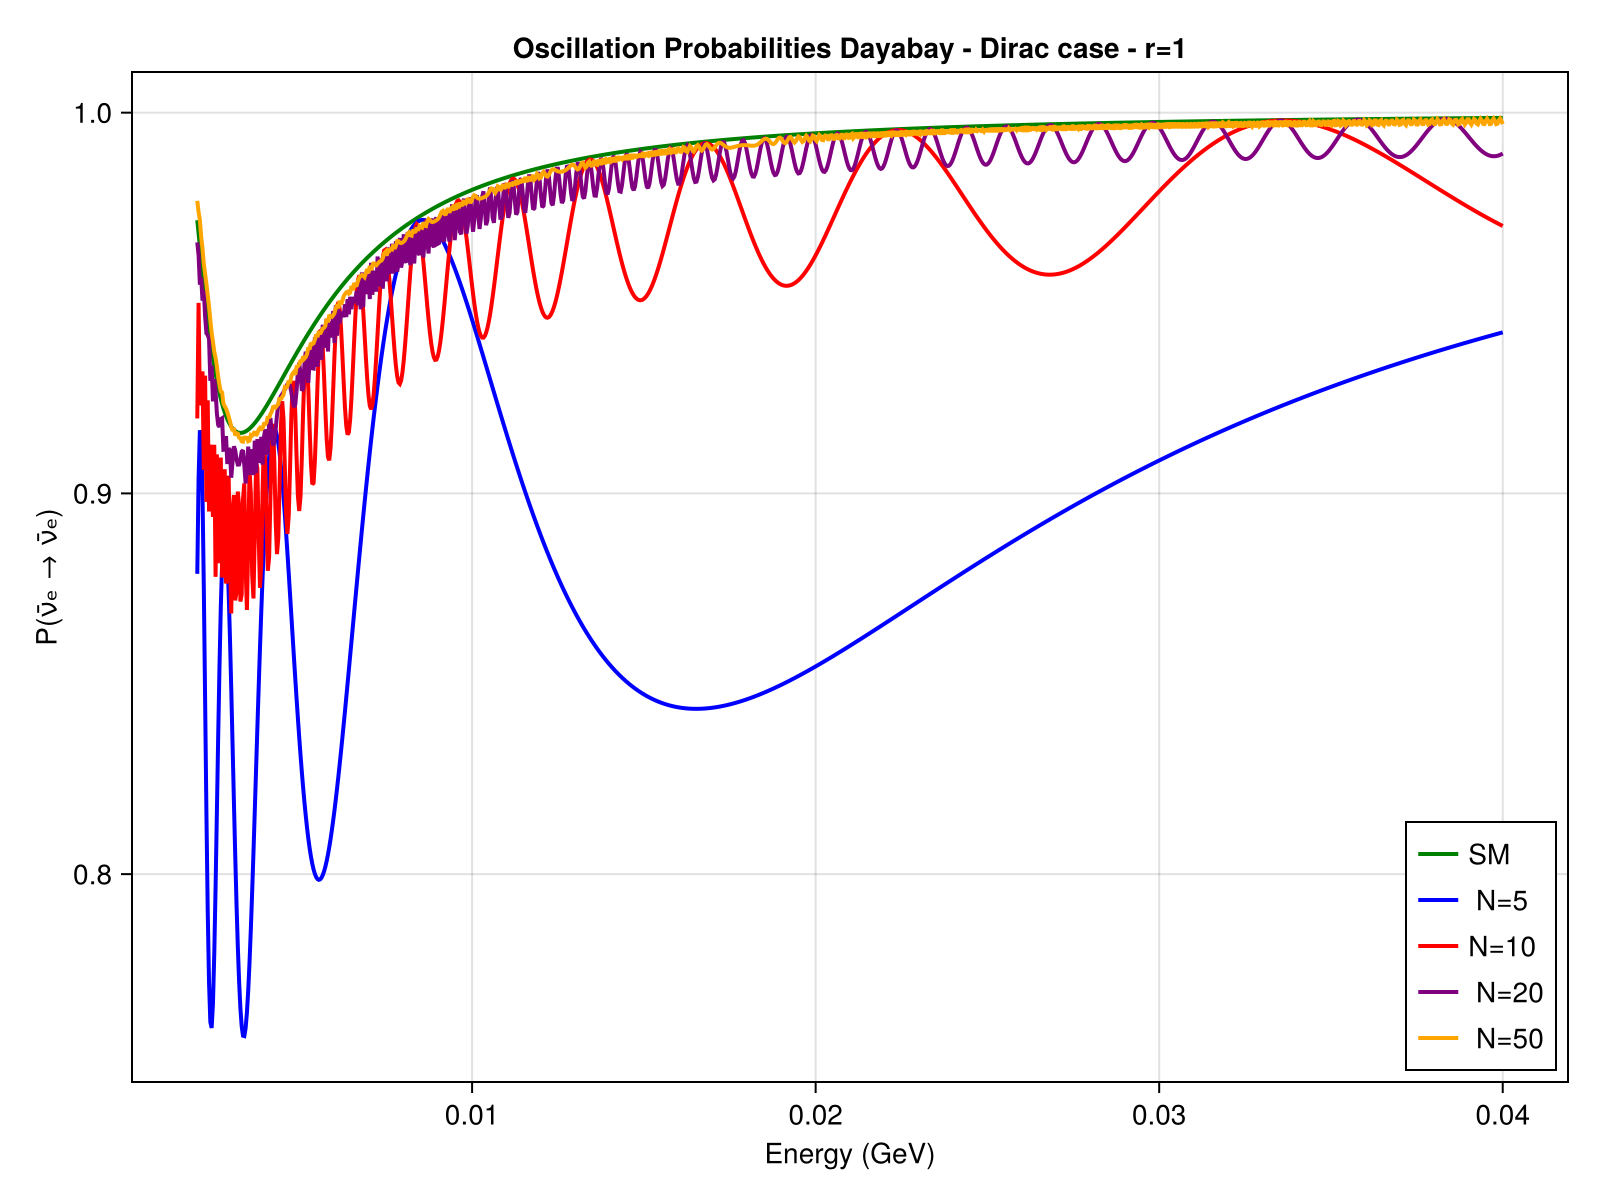

In [20]:

fig = Figure(size=(800, 600))
ax = Axis(fig[1,1], 
    xlabel = "Energy (GeV)",
    ylabel = "P(ν̄ₑ → ν̄ₑ)", 
    title = "Oscillation Probabilities Dayabay - Dirac case - r=1"
)

# Plot the lines
lines!(ax, E_range, probab_SM[:, 1, 1,1], label="SM", linewidth=2, color=:green)
lines!(ax, E_range, probab_5[:, 1, 1,1], label=" N=5", linewidth=2, color=:blue)
lines!(ax, E_range, probab_10[:, 1, 1,1], label="N=10", linewidth=2, color=:red)
lines!(ax, E_range, probab_20[:, 1,1,1], label=" N=20", linewidth=2, color=:purple)
lines!(ax, E_range, probab_50[:, 1,1,1], label=" N=50", linewidth=2, color=:orange)

# Add legend and set limits
axislegend(ax, position=:rb)
#save("/home/sofialon/Newtrinos.jl/natural plot/osc_dayabay_N_dirac.png", fig)

fig

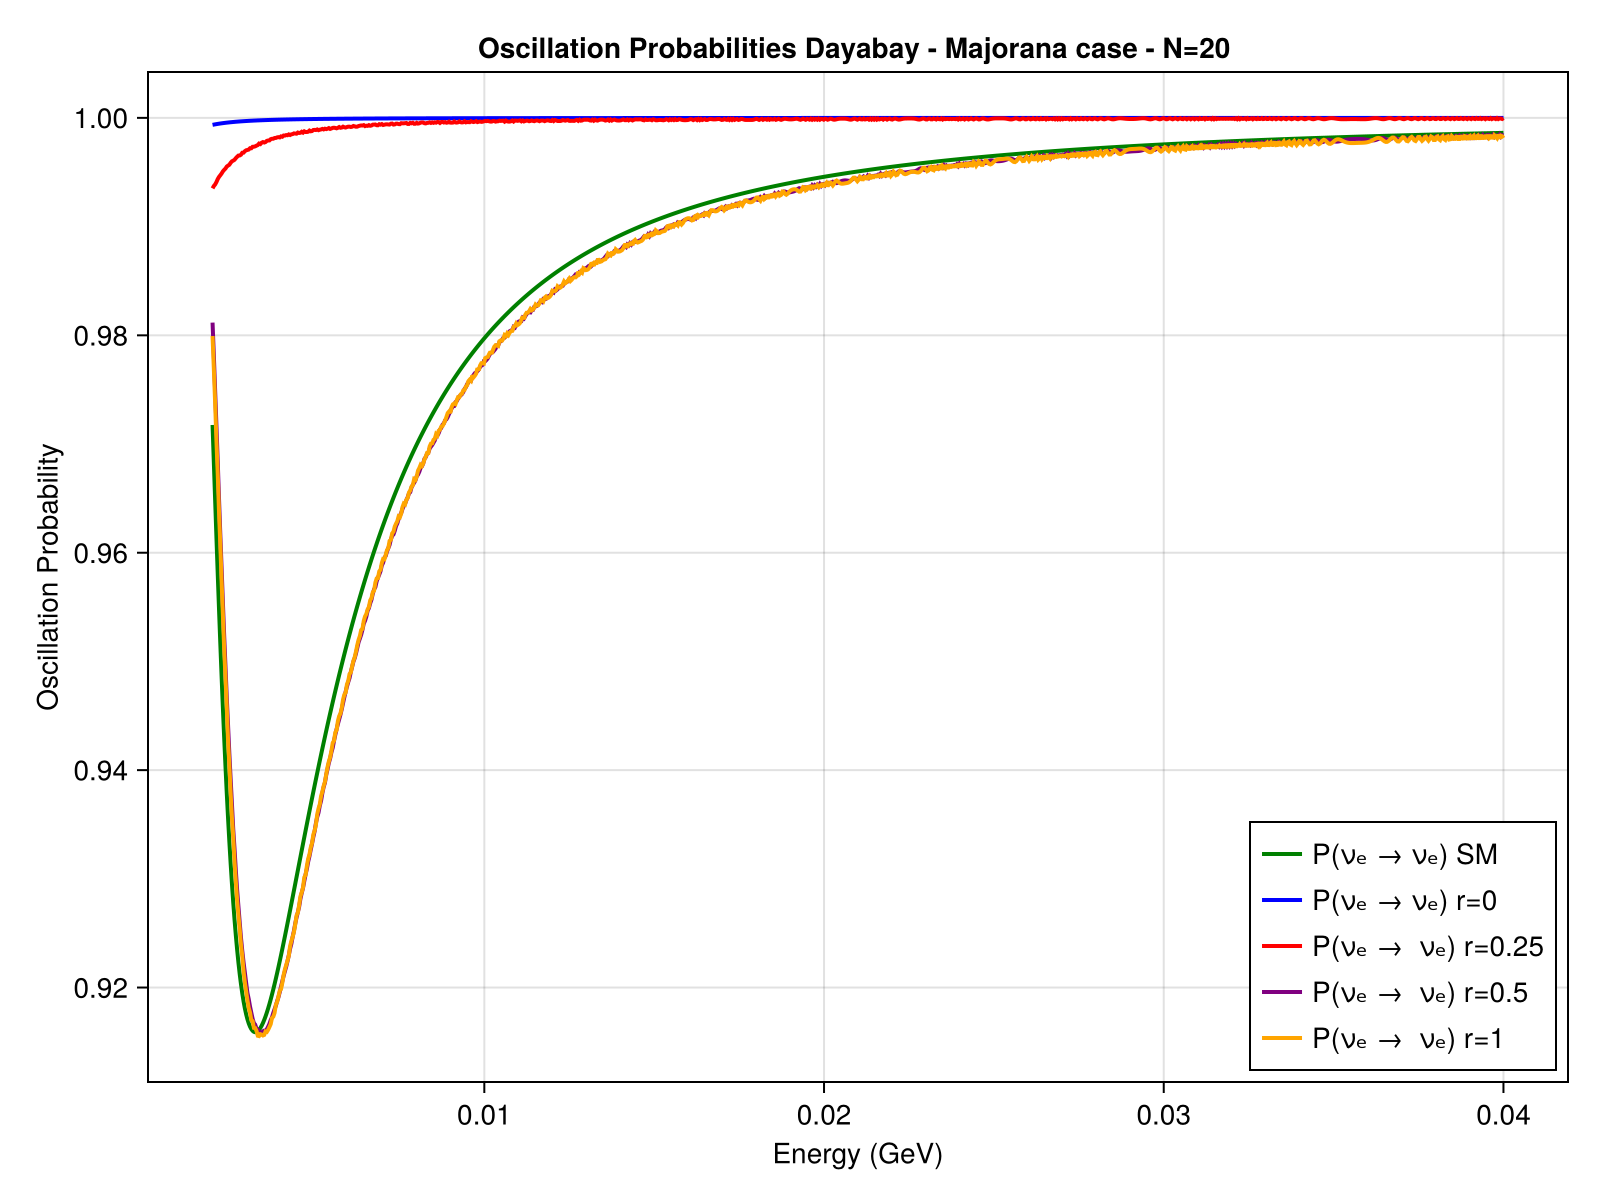

In [21]:

fig = Figure(size=(800, 600))
ax = Axis(fig[1,1], 
    xlabel = "Energy (GeV)",
    ylabel = "Oscillation Probability", 
    title = "Oscillation Probabilities Dayabay - Majorana case - N=20 "
)

# Plot the lines
lines!(ax, E_range, probab_SM[:, 1, 1, 1], label="P(νₑ → νₑ) SM", linewidth=2, color=:green)
lines!(ax, E_range, probab_0[:, 1, 1, 1], label="P(νₑ → νₑ) r=0", linewidth=2, color=:blue)
lines!(ax, E_range, probab_025[:, 1, 1, 1], label="P(νₑ →  νₑ) r=0.25", linewidth=2, color=:red)
lines!(ax, E_range, probab_05[:, 1, 1, 1], label="P(νₑ →  νₑ) r=0.5", linewidth=2, color=:purple)
lines!(ax, E_range, probab_1[:, 1, 1, 1], label="P(νₑ →  νₑ) r=1", linewidth=2, color=:orange)

# Add legend and set limits
axislegend(ax, position=:rb)
#save("/home/sofialon/Newtrinos.jl/natural plot/osc_dayabay_r_majorana.png", fig)

fig